
# TEM bacteriophage morphotype classifier

This notebook does four things:

1. Loads and cleans the metadata CSV.
2. Pads each TEM image to a square and resizes it to **265 × 265** pixels.
3. Trains a **CNN classifier** for the three morphotypes: **sipho, podo, myo** using an **80:20 train:test split**.
4. Plots **one-vs-rest ROC curves** for each class and provides a function to predict the morphotype of a new image.

The notebook is written to work with the files you supplied:

- `Selected.zip`
- `Selected_figures.csv`

Because the dataset is small, model performance can vary between runs. You can improve stability by adding more labelled images, using stronger augmentation, or training for more epochs.


In [1]:

import os
import zipfile
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageOps

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: cpu


In [2]:

# Update these paths if your files live elsewhere
ZIP_PATH = Path('/Users/vijinimallawaarachchi/Documents/Data/Phagebase/Selected.zip')
CSV_PATH = Path('/Users/vijinimallawaarachchi/Documents/Data/Phagebase/Selected_figures.csv')

WORK_DIR = Path('phage_tem_project')
RAW_DIR = WORK_DIR / 'raw'
EXTRACT_DIR = WORK_DIR / 'extracted'
PROCESSED_DIR = WORK_DIR / 'processed_265'
MODEL_PATH = WORK_DIR / 'tem_morphotype_cnn.pt'

WORK_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('ZIP exists:', ZIP_PATH.exists())
print('CSV exists:', CSV_PATH.exists())


ZIP exists: True
CSV exists: True


## 1) Load and standardise the metadata

In [3]:

metadata = pd.read_csv(CSV_PATH).copy()

# Standardise column names
metadata.columns = (
    metadata.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

# Standardise morphotype labels
morphotype_map = {
    'siphophage': 'sipho',
    'sipho': 'sipho',
    'podophage': 'podo',
    'podo': 'podo',
    'myophage': 'myo',
    'myo': 'myo'
}
metadata['morphotype_clean'] = (
    metadata['morphotype']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(morphotype_map)
)

# Standardise filename key
metadata['download_name'] = metadata['download_name'].astype(str).str.strip()
metadata['file_stem'] = metadata['download_name'].map(lambda x: Path(x).stem)

# Convert numeric columns where possible
for col in ['capsid_diameter_nm', 'length_head_to_tail', 'body_length']:
    if col in metadata.columns:
        metadata[col] = pd.to_numeric(metadata[col], errors='coerce')

metadata.head()


,name,image,image_templink,morphotype,phage_host,comments,attribution,date_added,capsid_diameter_nm,length_head_to_tail,body_length,download_name,morphotype_clean,file_stem
0,05F,image.png (https://v5.airtableusercontent.com/...,https://v5.airtableusercontent.com/v3/u/30/30/...,Myophage,Klebsiella pneumoniae,NaN,https://www.frontiersin.org/journals/microbiol...,"July 9, 2024",NaN,NaN,NaN,05F.png,myo,05F
1,113,image.png (https://v5.airtableusercontent.com/...,https://v5.airtableusercontent.com/v3/u/30/30/...,Myophage,"Shigella flexneri,Shigella sonnei,Shigella dys...",NaN,https://www.frontiersin.org/journals/microbiol...,"July 9, 2024",NaN,NaN,NaN,113.png,myo,113
2,1672,image.png (https://v5.airtableusercontent.com/...,https://v5.airtableusercontent.com/v3/u/30/30/...,Myophage,Hafnia alvei,Scale bars represent 50 nm. Image generously d...,https://www.phage.ulaval.ca/?pageDemandee=phag...,"May 23, 2024",NaN,NaN,NaN,1672.png,myo,1672
3,A1,image.png (https://v5.airtableusercontent.com/...,https://v5.airtableusercontent.com/v3/u/30/30/...,Myophage,Pseudomonas putida,NaN,https://www.nature.com/articles/s43705-022-001...,"May 26, 2024",NaN,NaN,NaN,A1.png,myo,A1
4,A2,image.png (https://v5.airtableusercontent.com/...,https://v5.airtableusercontent.com/v3/u/30/30/...,Myophage,Escherichia coli,Scale bars represent 50 nm. Image generously d...,https://www.phage.ulaval.ca/?pageDemandee=phag...,"May 23, 2024",NaN,NaN,NaN,A2_2.png,myo,A2_2


In [5]:

print('Metadata shape:', metadata.shape)
print('Morphotype counts from CSV:')
print(metadata['morphotype_clean'].value_counts(dropna=False))
print('Missing morphotype labels in CSV:', metadata['morphotype_clean'].isna().sum())
print('Duplicate file stems in CSV:', metadata['file_stem'].duplicated().sum())


Metadata shape: (51, 14)
Morphotype counts from CSV:
morphotype_clean
sipho    18
myo      17
podo     16
Name: count, dtype: int64
Missing morphotype labels in CSV: 0
Duplicate file stems in CSV: 0


## 2) Unzip image archive and create an image index

In [6]:

# Fresh extraction
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

# Find root folder containing class subfolders
candidate_root = EXTRACT_DIR / 'Selected'
if not candidate_root.exists():
    subdirs = [p for p in EXTRACT_DIR.iterdir() if p.is_dir() and not p.name.startswith('__MACOSX')]
    candidate_root = subdirs[0]

image_rows = []
valid_ext = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}
label_map_from_folder = {'sipho': 'sipho', 'sipho': 'sipho', 'podo': 'podo', 'myo': 'myo'}

for class_dir in candidate_root.iterdir():
    if not class_dir.is_dir() or class_dir.name.startswith('.') or class_dir.name.startswith('__MACOSX'):
        continue
    folder_label = label_map_from_folder.get(class_dir.name.strip().lower())
    if folder_label is None:
        continue

    for img_path in class_dir.iterdir():
        if img_path.name.startswith('.') or img_path.suffix.lower() not in valid_ext:
            continue
        try:
            with Image.open(img_path) as im:
                width, height = im.size
                mode = im.mode
            image_rows.append({
                'image_path': str(img_path),
                'filename': img_path.name,
                'file_stem': img_path.stem,
                'folder_label': folder_label,
                'width': width,
                'height': height,
                'mode': mode,
                'extension': img_path.suffix.lower()
            })
        except Exception as e:
            print(f'Skipping unreadable image {img_path.name}: {e}')

images_df = pd.DataFrame(image_rows)
images_df.head()


,image_path,filename,file_stem,folder_label,width,height,mode,extension
0,phage_tem_project/extracted/Selected/Myo/╧òD7.png,╧òD7.png,╧òD7,myo,117,199,RGBA,.png
1,phage_tem_project/extracted/Selected/Myo/╬ªBA-...,╬ªBA-1.png,╬ªBA-1,myo,426,604,RGBA,.png
2,phage_tem_project/extracted/Selected/Myo/PSPa_...,PSPa_2.png,PSPa_2,myo,310,308,RGBA,.png
3,phage_tem_project/extracted/Selected/Myo/44572...,44572.png,44572,myo,354,248,RGBA,.png
4,phage_tem_project/extracted/Selected/Myo/vB_Ec...,vB_EcoM_ESCO47.png,vB_EcoM_ESCO47,myo,274,264,RGBA,.png


In [7]:

print('Image count:', len(images_df))
print('Folder label counts:')
print(images_df['folder_label'].value_counts())

images_only = set(images_df['file_stem']) - set(metadata['file_stem'])
csv_only = set(metadata['file_stem']) - set(images_df['file_stem'])

print('Image stems not found in CSV:', sorted(images_only))
print('CSV stems not found in image folders:', sorted(csv_only))


Image count: 1063
Folder label counts:
folder_label
sipho    433
myo      386
podo     244
Name: count, dtype: int64
Image stems not found in CSV: ['121', '1214 Lindberg', '17', '1A', '2638A', '2811', '290F', '2D05', '2L372D', '2L372X', '2L372X_2', '311F', '3A', '3M', '3_K26', '4211', '44512', '44572', '4D05', '4D05_2', '4HA13', '4L372D', '4L372X', '4L372XY', '4L372XY_2', '4_C1334-76', '5093', '8101', 'A1_2', 'A2_3', 'A2_4', 'A2_5', 'A36', 'A3_2', 'A41', 'A511', 'A6', 'A7', 'A7_2', 'A8', 'AB27', 'AD1', 'AD2', 'APK116', 'APK2', 'APK32', 'APK37', 'APK44', 'APK48', 'APK87', 'APK89', 'APPa', 'APTC-SA-12', 'APTC-SA-13', 'APTC-SA-2', 'APTC-SA-4', 'ASG01', 'Ab_WF01', 'Abp95', 'Acp17', 'Adephagia', 'AerP_220', 'AhFM4', 'AhFM5', 'AhyVDH1', 'AmM-1', 'Anath', 'Anaya', 'Angelica', 'Apr-1', 'Artemius', 'Av-1', 'Ayka', 'Ayka_2', 'B', 'B277', 'BCJA1', 'BE', 'BECP10', 'BG3P', 'BH1', 'BL', 'BL3', 'BM-P1', 'BONAISHI', 'BS46', 'BTP1', 'BUCT549', 'BUCT549_2', 'BUCT555', 'BUCT556A', 'Ba2', 'Bakoly', 'Basti

## 3) Merge image index with metadata and resolve labels

In [8]:

dataset_df = images_df.merge(
    metadata,
    on='file_stem',
    how='left',
    suffixes=('', '_meta')
)

# Prefer CSV morphotype when available; otherwise fall back to folder label
# This is useful because the supplied CSV and image archive are not a perfect 1:1 filename match.
dataset_df['label'] = dataset_df['morphotype_clean'].fillna(dataset_df['folder_label'])

# Keep only rows with a valid final label
valid_labels = ['sipho', 'podo', 'myo']
dataset_df = dataset_df[dataset_df['label'].isin(valid_labels)].copy()

# Remove accidental duplicates by final filename if any
dataset_df = dataset_df.drop_duplicates(subset=['filename']).reset_index(drop=True)

print('Final dataset size:', len(dataset_df))
print(dataset_df['label'].value_counts())

dataset_df[['filename', 'folder_label', 'morphotype_clean', 'label', 'width', 'height']].head(10)


Final dataset size: 1063
label
sipho    433
myo      386
podo     244
Name: count, dtype: int64


,filename,folder_label,morphotype_clean,label,width,height
0,╧òD7.png,myo,NaN,myo,117,199
1,╬ªBA-1.png,myo,NaN,myo,426,604
2,PSPa_2.png,myo,NaN,myo,310,308
3,44572.png,myo,NaN,myo,354,248
4,vB_EcoM_ESCO47.png,myo,NaN,myo,274,264
5,K.png,myo,NaN,myo,191,182
6,A2_3.png,myo,NaN,myo,628,490
7,AD2.png,myo,NaN,myo,398,696
8,╧åMA1.png,myo,NaN,myo,352,372
9,phiCcoIBB37.png,myo,NaN,myo,600,602


## 4) Pre-process images: pad to square, resize to 265 × 265, and save cleaned copies

In [10]:

TARGET_SIZE = (265, 265)


def pad_to_square_and_resize(image: Image.Image, size=(265, 265), fill_color=255):
    """
    Convert image to grayscale, pad to square, then resize.
    fill_color=255 gives a white background which is usually sensible for TEM figures.
    """
    image = image.convert('L')
    width, height = image.size
    side = max(width, height)

    pad_left = (side - width) // 2
    pad_top = (side - height) // 2
    pad_right = side - width - pad_left
    pad_bottom = side - height - pad_top

    image = ImageOps.expand(
        image,
        border=(pad_left, pad_top, pad_right, pad_bottom),
        fill=fill_color
    )
    image = image.resize(size, Image.Resampling.LANCZOS)
    return image


# Clean output directory first so reruns stay deterministic
if PROCESSED_DIR.exists():
    shutil.rmtree(PROCESSED_DIR)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

processed_rows = []
for row in dataset_df.itertuples(index=False):
    out_dir = PROCESSED_DIR / row.label
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f'{Path(row.filename).stem}.png'

    with Image.open(row.image_path) as im:
        processed_im = pad_to_square_and_resize(im, size=TARGET_SIZE)
        processed_im.save(out_path)

    processed_rows.append({
        'processed_path': str(out_path),
        'label': row.label,
        'filename': row.filename,
        'file_stem': row.file_stem
    })

processed_df = pd.DataFrame(processed_rows)
print(processed_df.head())
print('Processed image counts:')
print(processed_df['label'].value_counts())


/Users/vijinimallawaarachchi/miniforge3/envs/phagemorph/lib/python3.10/site-packages/PIL/Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


                                      processed_path label  \
0       phage_tem_project/processed_265/myo/╧òD7.png   myo   
1     phage_tem_project/processed_265/myo/╬ªBA-1.png   myo   
2     phage_tem_project/processed_265/myo/PSPa_2.png   myo   
3      phage_tem_project/processed_265/myo/44572.png   myo   
4  phage_tem_project/processed_265/myo/vB_EcoM_ES...   myo   

             filename       file_stem  
0            ╧òD7.png            ╧òD7  
1          ╬ªBA-1.png          ╬ªBA-1  
2          PSPa_2.png          PSPa_2  
3           44572.png           44572  
4  vB_EcoM_ESCO47.png  vB_EcoM_ESCO47  
Processed image counts:
label
sipho    433
myo      386
podo     244
Name: count, dtype: int64


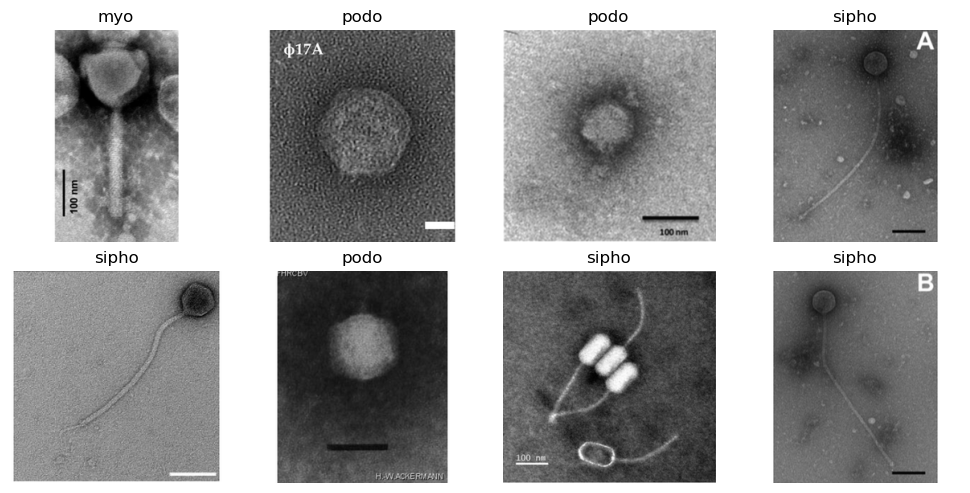

In [11]:

# Quick visual sanity check
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, row in zip(axes.ravel(), processed_df.sample(min(8, len(processed_df)), random_state=SEED).itertuples(index=False)):
    img = Image.open(row.processed_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(row.label)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 5) Train:test split (80:20, stratified)

In [13]:

train_df, test_df = train_test_split(
    processed_df,
    test_size=0.20,
    random_state=SEED,
    stratify=processed_df['label']
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Train size:', len(train_df))
print('Test size:', len(test_df))
print('Train label counts:')
print(train_df['label'].value_counts())
print('Test label counts:')
print(test_df['label'].value_counts())


Train size: 850
Test size: 213
Train label counts:
label
sipho    346
myo      309
podo     195
Name: count, dtype: int64
Test label counts:
label
sipho    87
myo      77
podo     49
Name: count, dtype: int64


## 6) PyTorch dataset and dataloaders

In [14]:

class_names = ['sipho', 'podo', 'myo']
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}


def pil_to_tensor(img: Image.Image):
    arr = np.asarray(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)  # (1, H, W)
    return torch.tensor(arr, dtype=torch.float32)


class TEMDataset(Dataset):
    def __init__(self, dataframe, augment=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.dataframe)

    def _augment(self, img):
        # Light augmentation for a small dataset
        if np.random.rand() < 0.5:
            img = ImageOps.mirror(img)
        if np.random.rand() < 0.5:
            img = ImageOps.flip(img)
        if np.random.rand() < 0.5:
            angle = np.random.uniform(-15, 15)
            img = img.rotate(angle, fillcolor=255)
        return img

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img = Image.open(row['processed_path']).convert('L')
        if self.augment:
            img = self._augment(img)
        x = pil_to_tensor(img)
        y = class_to_idx[row['label']]
        return x, y


BATCH_SIZE = 8

train_ds = TEMDataset(train_df, augment=True)
test_ds = TEMDataset(test_df, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


## 7) Define the CNN model

In [15]:

class PhageMorphotypeCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = PhageMorphotypeCNN(num_classes=len(class_names)).to(DEVICE)
print(model)


PhageMorphotypeCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0

## 8) Train the CNN

In [17]:

EPOCHS = 20
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * x_batch.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'train_loss={train_loss:.4f} train_acc={train_acc:.3f} | '
          f'test_loss={test_loss:.4f} test_acc={test_acc:.3f}')

# Save trained weights and class mapping
checkpoint = {
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'target_size': TARGET_SIZE,
}
torch.save(checkpoint, MODEL_PATH)
print(f'Saved model to: {MODEL_PATH}')


Epoch 01/20 | train_loss=3.5384 train_acc=0.400 | test_loss=1.0467 test_acc=0.404
Epoch 02/20 | train_loss=1.0631 train_acc=0.433 | test_loss=1.0338 test_acc=0.404
Epoch 03/20 | train_loss=1.0624 train_acc=0.418 | test_loss=1.0544 test_acc=0.432
Epoch 04/20 | train_loss=1.0629 train_acc=0.426 | test_loss=1.0330 test_acc=0.451
Epoch 05/20 | train_loss=1.0437 train_acc=0.462 | test_loss=1.0238 test_acc=0.521
Epoch 06/20 | train_loss=1.0280 train_acc=0.458 | test_loss=1.0285 test_acc=0.474
Epoch 07/20 | train_loss=1.0293 train_acc=0.434 | test_loss=0.9917 test_acc=0.493
Epoch 08/20 | train_loss=1.0414 train_acc=0.427 | test_loss=1.0709 test_acc=0.413
Epoch 09/20 | train_loss=1.0330 train_acc=0.440 | test_loss=1.0351 test_acc=0.441
Epoch 10/20 | train_loss=1.0240 train_acc=0.433 | test_loss=1.0450 test_acc=0.427
Epoch 11/20 | train_loss=1.0218 train_acc=0.458 | test_loss=1.0230 test_acc=0.460
Epoch 12/20 | train_loss=1.0303 train_acc=0.451 | test_loss=1.0202 test_acc=0.455
Epoch 13/20 | tr

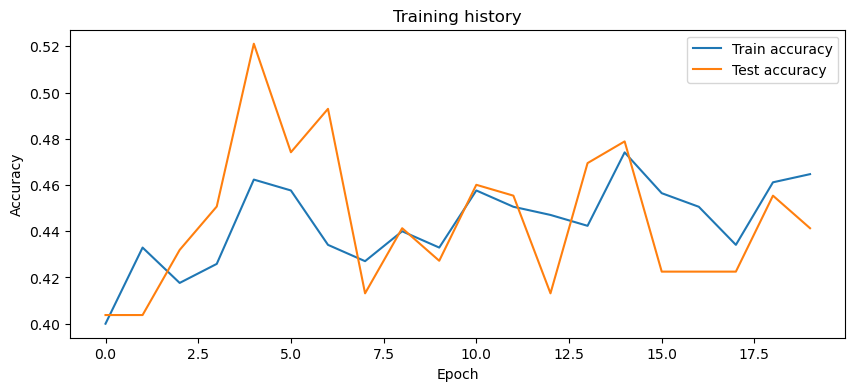

In [18]:

plt.figure(figsize=(10, 4))
plt.plot(history['train_acc'], label='Train accuracy')
plt.plot(history['test_acc'], label='Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training history')
plt.legend()
plt.show()


## 9) Evaluate model performance and plot ROC curves for each class

In [19]:

model.eval()
all_probs = []
all_true = []
all_pred = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(DEVICE)
        logits = model(x_batch)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        all_probs.append(probs)
        all_true.append(y_batch.numpy())
        all_pred.append(preds)

all_probs = np.vstack(all_probs)
all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

print(classification_report(all_true, all_pred, target_names=class_names, zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(all_true, all_pred))


              precision    recall  f1-score   support

       sipho       0.43      0.98      0.60        87
        podo       0.50      0.08      0.14        49
         myo       0.62      0.06      0.12        77

    accuracy                           0.44       213
   macro avg       0.52      0.37      0.29       213
weighted avg       0.52      0.44      0.32       213

Confusion matrix:
[[85  1  1]
 [43  4  2]
 [69  3  5]]


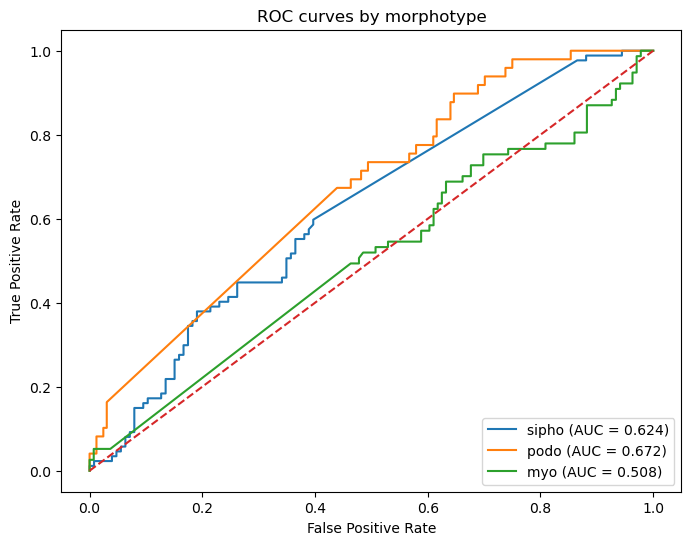

In [20]:

# One-vs-rest ROC curves
true_binarized = label_binarize(all_true, classes=np.arange(len(class_names)))

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(true_binarized[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves by morphotype')
plt.legend(loc='lower right')
plt.show()


## 10) Predict the morphotype of your own image

In [21]:

def load_trained_model(model_path=MODEL_PATH, device=DEVICE):
    checkpoint = torch.load(model_path, map_location=device)
    class_names_loaded = checkpoint['class_names']
    model_loaded = PhageMorphotypeCNN(num_classes=len(class_names_loaded)).to(device)
    model_loaded.load_state_dict(checkpoint['model_state_dict'])
    model_loaded.eval()
    return model_loaded, class_names_loaded


@torch.no_grad()
def predict_morphotype(image_path, model=None, class_names_local=None, device=DEVICE, show_image=True):
    """
    Predict morphotype for a single TEM image.

    Example:
        predict_morphotype('/path/to/my_image.png')
    """
    if model is None or class_names_local is None:
        model, class_names_local = load_trained_model()

    with Image.open(image_path) as im:
        processed = pad_to_square_and_resize(im, size=TARGET_SIZE)

    x = pil_to_tensor(processed).unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = int(np.argmax(probs))
    pred_label = class_names_local[pred_idx]

    result = pd.DataFrame({
        'class': class_names_local,
        'probability': probs
    }).sort_values('probability', ascending=False).reset_index(drop=True)

    if show_image:
        plt.figure(figsize=(4, 4))
        plt.imshow(processed, cmap='gray')
        plt.title(f'Predicted morphotype: {pred_label}')
        plt.axis('off')
        plt.show()

    return pred_label, result


In [22]:

# Example usage:
# Replace with your own image path
# my_image_path = '/mnt/data/my_new_tem_image.png'
# pred_label, pred_table = predict_morphotype(my_image_path)
# print('Predicted morphotype:', pred_label)
# display(pred_table)



## Notes

- The notebook uses **grayscale images** because TEM images are effectively intensity-based.
- Padding is applied before resizing so rectangular figures become square without distortion.
- The dataset is small, so ROC curves and accuracy can vary noticeably.
- The CSV and image archive contain a small number of filename mismatches. This notebook resolves class labels by preferring the CSV morphotype when matched and otherwise falling back to the class folder name.
- If you want, the next improvement would be to add cross-validation, class-balanced sampling, or a stronger CNN/transfer-learning model.
